# B_S3.3 - Metric Selection with Train/Validation, Ablation, and Sparse Search

Goal: find a **small metric set** that keeps detection power close to the full metric set while maintaining FPR near 0.05.

This notebook fixes the main limitation of B_S3.2: it does not use the same data both to choose metrics and to report final performance.

Design:

1. Split cases into train and validation, stratified by `category + x_distribution`.
2. Use train only for calibration, ranking, ablation-driven candidate discovery, and threshold fitting.
3. Use validation only for held-out reporting.
4. Compare full-safe metrics, metric groups, leave-one-group-out, leave-one-metric-out, and sparse combinations.

Selection target:

- H0: `true_null`
- H1: `mean_only + variance_only + mean+variance`
- Main metric: validation overall power on all signal cases
- Constraint: validation FPR should stay close to 0.05
- Preference: choose the smallest metric set within 1 percentage point of full-safe validation power


In [19]:
from pathlib import Path
from itertools import combinations
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.dpi': 120,
    'figure.facecolor': 'white',
    'axes.grid': True,
    'grid.alpha': 0.3,
})

S1_DIR = Path('output/S1')
S3_DIR = Path('output/S3')
OUT_DIR = Path('output/S3.3')
OUT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 20260623
ALPHA = 0.05
TRAIN_FRACTION = 0.5

# Exact exhaustive subset search is only feasible for small k.
MAX_EXACT_K = 3
MAX_EXACT_COMBOS = 75_000
MAX_SPARSE_K = 8
BEAM_WIDTH = 60
NEAR_FULL_TOL = 0.01
VALIDATION_FPR_LIMIT = 0.08


## 1. Load B_S3 Results and Metadata

Run this notebook from the `B/` directory, because paths are relative to `B/`.


In [20]:
df = pd.read_parquet(S3_DIR / 'permutation_all.parquet')
Z_COLS = sorted([c for c in df.columns if c.startswith('z_')])
P_COLS = sorted([c for c in df.columns if c.startswith('p_') and c != 'p_value'])

cases_main = pd.read_csv(S1_DIR / 'cases.csv', low_memory=False)
cases_null = pd.read_csv(S1_DIR / 'null_expanded_cases.csv', low_memory=False)
cases_null['case_id'] = cases_null['case_id'] + cases_main['case_id'].max()

meta_cols = ['case_id', 'family_id', 'snr', 'spread_pattern', 'x_distribution']
cases_all = pd.concat([cases_main[meta_cols], cases_null[meta_cols]], ignore_index=True)
df = df.merge(cases_all, on='case_id', how='left')

is_null_family = df['family_id'] == 'Null'
is_constant_spread = df['spread_pattern'] == 'constant'

df['category'] = 'mean+variance'
df.loc[is_null_family & is_constant_spread, 'category'] = 'true_null'
df.loc[~is_null_family & is_constant_spread, 'category'] = 'mean_only'
df.loc[is_null_family & ~is_constant_spread, 'category'] = 'variance_only'

print(f'B_S3 output: {len(df):,} cases x {len(Z_COLS)} Z-score metrics')
print(f'Source: {df["source"].value_counts().to_dict()}')
print('\nCategories:')
print(df['category'].value_counts().to_string())

partial = []
for zc in Z_COLS:
    n_valid = int(df[zc].notna().sum())
    if n_valid < len(df):
        partial.append((zc, n_valid, len(df)))
if partial:
    print('\nMetrics with partial coverage:')
    for zc, n_valid, n_total in partial:
        print(f'  {zc}: {n_valid:,}/{n_total:,} non-null')


B_S3 output: 17,008 cases x 44 Z-score metrics
Source: {'main': 10128, 'null_expanded': 6880}

Categories:
category
mean_only        5000
mean+variance    5000
true_null        4032
variance_only    2976

Metrics with partial coverage:
  z_lowess_r2: 9,008/17,008 non-null
  z_mas: 9,008/17,008 non-null
  z_mcn: 9,008/17,008 non-null
  z_mev: 9,008/17,008 non-null
  z_mic: 9,008/17,008 non-null


## 2. Metric Display Names and Groups


In [21]:
def metric_display(col):
    name = col.replace('z_', '')
    replacements = {
        'abs_pearson_r': '|pearson|',
        'abs_spearman_rho': '|spearman|',
        'abs_covariance': '|covariance|',
    }
    return replacements.get(name, name)

METRIC_DISPLAY = {c: metric_display(c) for c in Z_COLS}

METRIC_GROUPS = {}
for c in Z_COLS:
    name = c.replace('z_', '')
    if name in ('pearson', 'spearman', 'abs_pearson_r', 'abs_spearman_rho', 'abs_covariance'):
        METRIC_GROUPS[c] = 'correlation'
    elif 'dcor' in name or 'dcov' in name:
        METRIC_GROUPS[c] = 'distance'
    elif 'ep_' in name or 'pf_' in name or 'seg_' in name:
        METRIC_GROUPS[c] = 'slope'
    elif 'bin_' in name or name == 'eta2':
        METRIC_GROUPS[c] = 'bin'
    elif 'dist_' in name:
        METRIC_GROUPS[c] = 'distribution'
    elif name in ('mic', 'mas', 'mev', 'mcn'):
        METRIC_GROUPS[c] = 'mine'
    elif name == 'lowess_r2':
        METRIC_GROUPS[c] = 'nonlinear'
    else:
        METRIC_GROUPS[c] = 'other'

GROUP_COLORS = {
    'correlation': '#e41a1c',
    'distance': '#377eb8',
    'slope': '#4daf4a',
    'bin': '#ff7f00',
    'distribution': '#984ea3',
    'mine': '#a65628',
    'nonlinear': '#f781bf',
    'other': '#999999',
}

print('Metric groups:')
for group in sorted(set(METRIC_GROUPS.values())):
    members = [c for c in Z_COLS if METRIC_GROUPS[c] == group]
    print(f'  {group:12s}: {len(members):2d} metrics')


Metric groups:
  bin         : 12 metrics
  correlation :  3 metrics
  distance    :  2 metrics
  distribution:  4 metrics
  mine        :  4 metrics
  nonlinear   :  1 metrics
  slope       : 18 metrics


## 3. Stratified Train/Validation Split

The split is stratified by `category + x_distribution`. All selection operations use train only.


In [22]:
rng = np.random.default_rng(RANDOM_SEED)
df['split'] = 'validation'

for _, idx in df.groupby(['category', 'x_distribution'], dropna=False).groups.items():
    idx = np.array(list(idx)).copy()
    rng.shuffle(idx)
    n_train = int(round(len(idx) * TRAIN_FRACTION))
    if len(idx) > 1:
        n_train = min(max(n_train, 1), len(idx) - 1)
    df.loc[idx[:n_train], 'split'] = 'train'

train = df[df['split'] == 'train'].copy()
validation = df[df['split'] == 'validation'].copy()

split_counts = df.groupby(['split', 'category']).size().unstack(fill_value=0)
print(split_counts)
print('\nFraction train by category:')
print((split_counts.loc['train'] / split_counts.sum(axis=0)).to_string(float_format='{:.3f}'.format))


category    mean+variance  mean_only  true_null  variance_only
split                                                         
train                2500       2500       2016           1488
validation           2500       2500       2016           1488

Fraction train by category:
category
mean+variance   0.500
mean_only       0.500
true_null       0.500
variance_only   0.500


## 4. Evaluation Helpers

Every combination uses the same statistic:

```text
T_combo = max(Z_metric for metric in combo)
```

The threshold is fit from train true_null only. Missing values are counted as not detected in evaluation, which is conservative for subset-only metrics such as MINE/LOWESS.


In [23]:
def fit_threshold(data, metrics, alpha=ALPHA):
    null_data = data[data['category'] == 'true_null']
    T_null = null_data[metrics].max(axis=1).dropna()
    if len(T_null) == 0:
        return np.nan
    return float(np.nanpercentile(T_null, 100 * (1 - alpha)))


def evaluate_fixed_threshold(data, metrics, threshold):
    T = data[metrics].max(axis=1)
    detected = (T > threshold).fillna(False)

    out = {
        'n_metrics': len(metrics),
        'threshold': threshold,
        'n_total': len(data),
    }
    for cat in ['true_null', 'mean_only', 'variance_only', 'mean+variance']:
        mask = data['category'] == cat
        out[f'n_{cat}'] = int(mask.sum())
        out[f'rate_{cat}'] = float(detected[mask].mean()) if mask.sum() else np.nan

    signal_mask = data['category'] != 'true_null'
    out['overall_power'] = float(detected[signal_mask].mean()) if signal_mask.sum() else np.nan
    out['detected'] = detected
    out['T'] = T
    return out


def fit_and_evaluate(train_data, eval_data, metrics, alpha=ALPHA):
    threshold = fit_threshold(train_data, metrics, alpha=alpha)
    result = evaluate_fixed_threshold(eval_data, metrics, threshold)
    result['metrics'] = tuple(metrics)
    return result


def result_row(result, prefix):
    return {
        f'{prefix}_overall_power': result['overall_power'],
        f'{prefix}_FPR': result['rate_true_null'],
        f'{prefix}_MO': result['rate_mean_only'],
        f'{prefix}_VO': result['rate_variance_only'],
        f'{prefix}_MV': result['rate_mean+variance'],
    }


def evaluate_combo_train_validation(metrics, label=None, kind=None):
    metrics = list(metrics)
    train_result = fit_and_evaluate(train, train, metrics, alpha=ALPHA)
    val_result = evaluate_fixed_threshold(validation, metrics, train_result['threshold'])
    row = {
        'label': label or ', '.join(METRIC_DISPLAY[m] for m in metrics),
        'kind': kind or 'combo',
        'k': len(metrics),
        'metrics': ','.join(metrics),
        'display_metrics': ', '.join(METRIC_DISPLAY[m] for m in metrics),
        'threshold_from_train': train_result['threshold'],
        'has_mine': any(METRIC_GROUPS[m] == 'mine' for m in metrics),
    }
    row.update(result_row(train_result, 'train'))
    row.update(result_row(val_result, 'validation'))
    return row, train_result, val_result


def print_eval_table(table, max_rows=30):
    cols = ['label', 'k', 'train_overall_power', 'train_FPR',
            'validation_overall_power', 'validation_FPR',
            'validation_MO', 'validation_VO', 'validation_MV']
    print(table[cols].head(max_rows).to_string(index=False, float_format='{:.3f}'.format))


## 5. Train-Only Calibration Screen

This screen removes degenerate or badly behaved metrics before sparse selection. It uses train true_null only.


In [24]:
train_null = train[train['category'] == 'true_null']
calib_rows = []
for zc in Z_COLS:
    z_null = train_null[zc].dropna()
    pc = zc.replace('z_', 'p_')
    p_null = train_null[pc].dropna() if pc in train_null.columns else pd.Series(dtype=float)
    empirical_fpr = float((p_null <= ALPHA).mean()) if len(p_null) else np.nan
    calib_rows.append({
        'metric': zc,
        'display': METRIC_DISPLAY[zc],
        'group': METRIC_GROUPS[zc],
        'n_valid_train_null': int(len(z_null)),
        'mean_train_null': float(z_null.mean()) if len(z_null) else np.nan,
        'std_train_null': float(z_null.std()) if len(z_null) > 1 else np.nan,
        'q95_train_null': float(np.nanpercentile(z_null, 95)) if len(z_null) else np.nan,
        'empirical_p_fpr_train_null': empirical_fpr,
    })

calib = pd.DataFrame(calib_rows)
calib['flag_bias'] = calib['mean_train_null'].abs() > 1.0
calib['flag_degen'] = calib['std_train_null'] < 0.3
calib['flag_unstable'] = calib['std_train_null'] > 3.0
calib['flag_high_p_fpr'] = calib['empirical_p_fpr_train_null'] > 0.15
calib['flagged'] = calib[['flag_bias', 'flag_degen', 'flag_unstable', 'flag_high_p_fpr']].any(axis=1)

SAFE_METRICS = calib.loc[~calib['flagged'], 'metric'].tolist()
FULL_COVERAGE_SAFE_METRICS = [m for m in SAFE_METRICS if train[m].notna().all() and validation[m].notna().all()]

print(f'Safe metrics: {len(SAFE_METRICS)} / {len(Z_COLS)}')
print(f'Full-coverage safe metrics: {len(FULL_COVERAGE_SAFE_METRICS)} / {len(SAFE_METRICS)}')

if calib['flagged'].any():
    print('\nFlagged metrics:')
    print(calib.loc[calib['flagged'], ['display', 'group', 'mean_train_null', 'std_train_null', 'empirical_p_fpr_train_null']]
          .sort_values('empirical_p_fpr_train_null', ascending=False)
          .to_string(index=False, float_format='{:.3f}'.format))

calib.to_csv(OUT_DIR / 'train_null_calibration.csv', index=False, float_format='%.6f')


Safe metrics: 43 / 44
Full-coverage safe metrics: 39 / 43

Flagged metrics:
display group  mean_train_null  std_train_null  empirical_p_fpr_train_null
    mcn  mine            0.000           0.000                       0.000


## 6. Full Benchmarks

These are the upper-reference baselines. Final sparse combinations are compared against `all_safe` validation power.


In [25]:
benchmark_specs = [
    ('all_metrics', Z_COLS),
    ('all_safe', SAFE_METRICS),
    ('full_coverage_safe', FULL_COVERAGE_SAFE_METRICS),
]

benchmark_rows = []
for label, metrics in benchmark_specs:
    if len(metrics) == 0:
        continue
    row, _, _ = evaluate_combo_train_validation(metrics, label=label, kind='benchmark')
    benchmark_rows.append(row)

benchmarks = pd.DataFrame(benchmark_rows).sort_values('validation_overall_power', ascending=False)
benchmarks.to_csv(OUT_DIR / 'full_benchmarks.csv', index=False, float_format='%.6f')
print_eval_table(benchmarks)

FULL_SAFE_POWER = float(benchmarks.loc[benchmarks['label'] == 'all_safe', 'validation_overall_power'].iloc[0])
print(f'\nFull-safe validation power reference: {FULL_SAFE_POWER:.3f}')


             label  k  train_overall_power  train_FPR  validation_overall_power  validation_FPR  validation_MO  validation_VO  validation_MV
       all_metrics 44                0.982      0.050                     0.979           0.062          0.965          0.972          0.998
          all_safe 43                0.982      0.050                     0.979           0.062          0.965          0.972          0.998
full_coverage_safe 39                0.980      0.050                     0.979           0.056          0.966          0.968          0.998

Full-safe validation power reference: 0.979


## 7. Individual Metrics: Best k=1

This answers: which metric alone has the highest held-out performance?


In [26]:
individual_rows = []
for metric in SAFE_METRICS:
    row, _, _ = evaluate_combo_train_validation([metric], label=METRIC_DISPLAY[metric], kind='individual')
    row['group'] = METRIC_GROUPS[metric]
    individual_rows.append(row)

individual = pd.DataFrame(individual_rows).sort_values('train_overall_power', ascending=False)
individual.to_csv(OUT_DIR / 'individual_metric_train_validation.csv', index=False, float_format='%.6f')

print('Top individual metrics by train power; validation is held out:')
print(individual[['label', 'group', 'train_overall_power', 'train_FPR',
                  'validation_overall_power', 'validation_FPR',
                  'validation_MO', 'validation_VO', 'validation_MV']]
      .head(25).to_string(index=False, float_format='{:.3f}'.format))


Top individual metrics by train power; validation is held out:
             label        group  train_overall_power  train_FPR  validation_overall_power  validation_FPR  validation_MO  validation_VO  validation_MV
              dcov     distance                0.983      0.050                     0.979           0.050          0.953          0.987          1.000
              dcor     distance                0.983      0.050                     0.979           0.050          0.953          0.987          1.000
      ec_dist_wass distribution                0.906      0.050                     0.900           0.062          0.910          0.763          0.972
        ew_dist_ks distribution                0.904      0.050                     0.900           0.054          0.901          0.784          0.968
      ew_dist_wass distribution                0.902      0.050                     0.897           0.059          0.908          0.769          0.963
        ec_dist_ks distribution

## 8. Group-Only and Leave-One-Group-Out Ablation

Group-only asks: how much can this metric family do by itself?

Leave-one-group-out asks: how much does performance drop when this family is removed from the full safe set?


In [27]:
group_rows = []
groups = sorted(set(METRIC_GROUPS[m] for m in SAFE_METRICS))

for group in groups:
    group_metrics = [m for m in SAFE_METRICS if METRIC_GROUPS[m] == group]
    if group_metrics:
        row, _, _ = evaluate_combo_train_validation(group_metrics, label=f'{group} only', kind='group_only')
        row['group'] = group
        group_rows.append(row)

for group in groups:
    remaining = [m for m in SAFE_METRICS if METRIC_GROUPS[m] != group]
    if remaining:
        row, _, _ = evaluate_combo_train_validation(remaining, label=f'all_safe - {group}', kind='leave_one_group_out')
        row['group_removed'] = group
        row['validation_power_drop_vs_full_safe'] = FULL_SAFE_POWER - row['validation_overall_power']
        group_rows.append(row)

group_ablation = pd.DataFrame(group_rows)
group_ablation.to_csv(OUT_DIR / 'group_ablation_train_validation.csv', index=False, float_format='%.6f')

print('Group-only performance:')
print_eval_table(group_ablation[group_ablation['kind'] == 'group_only'].sort_values('validation_overall_power', ascending=False))

print('\nLeave-one-group-out performance:')
leave_group = group_ablation[group_ablation['kind'] == 'leave_one_group_out'].sort_values('validation_power_drop_vs_full_safe', ascending=False)
cols = ['label', 'k', 'validation_overall_power', 'validation_FPR', 'validation_power_drop_vs_full_safe', 'validation_MO', 'validation_VO', 'validation_MV']
print(leave_group[cols].to_string(index=False, float_format='{:.3f}'.format))


Group-only performance:
            label  k  train_overall_power  train_FPR  validation_overall_power  validation_FPR  validation_MO  validation_VO  validation_MV
    distance only  2                0.983      0.050                     0.979           0.050          0.953          0.987          1.000
         bin only 12                0.957      0.050                     0.954           0.060          0.963          0.868          0.995
distribution only  4                0.922      0.050                     0.919           0.058          0.929          0.798          0.982
 correlation only  3                0.760      0.050                     0.755           0.056          0.909          0.228          0.915
       slope only 18                0.745      0.050                     0.739           0.050          0.934          0.082          0.934
        mine only  3                0.358      0.050                     0.353           0.065          0.172          0.920          0.

## 9. Leave-One-Metric-Out Ablation

This asks: from the full safe set, which single metric removal causes the biggest validation power drop?

A large drop means the metric has unique contribution not fully covered by the rest.


In [28]:
metric_ablation_rows = []
for metric in SAFE_METRICS:
    remaining = [m for m in SAFE_METRICS if m != metric]
    if not remaining:
        continue
    row, _, _ = evaluate_combo_train_validation(remaining, label=f'all_safe - {METRIC_DISPLAY[metric]}', kind='leave_one_metric_out')
    row['metric_removed'] = metric
    row['display_removed'] = METRIC_DISPLAY[metric]
    row['group_removed'] = METRIC_GROUPS[metric]
    row['validation_power_drop_vs_full_safe'] = FULL_SAFE_POWER - row['validation_overall_power']
    metric_ablation_rows.append(row)

metric_ablation = pd.DataFrame(metric_ablation_rows).sort_values('validation_power_drop_vs_full_safe', ascending=False)
metric_ablation.to_csv(OUT_DIR / 'metric_ablation_train_validation.csv', index=False, float_format='%.6f')

print('Top leave-one-metric-out drops:')
print(metric_ablation[['display_removed', 'group_removed', 'validation_power_drop_vs_full_safe',
                       'validation_overall_power', 'validation_FPR', 'validation_MO', 'validation_VO', 'validation_MV']]
      .head(25).to_string(index=False, float_format='{:.4f}'.format))


Top leave-one-metric-out drops:
 display_removed group_removed  validation_power_drop_vs_full_safe  validation_overall_power  validation_FPR  validation_MO  validation_VO  validation_MV
   ew_bin_bw_mid           bin                              0.0012                    0.9780          0.0615         0.9644         0.9677         0.9976
   ec_bin_bw_mid           bin                              0.0006                    0.9786          0.0625         0.9652         0.9698         0.9972
      ew_bin_amp           bin                              0.0005                    0.9787          0.0635         0.9636         0.9724         0.9976
    ec_dist_wass  distribution                              0.0005                    0.9787          0.0630         0.9648         0.9704         0.9976
      ew_dist_ks  distribution                              0.0003                    0.9789          0.0615         0.9652         0.9704         0.9976
             mas          mine              

## 10. Exact Best Subset for Small k

This is the direct version of:

```text
k=1: best single metric
k=2: best pair
k=3: best triple
```

Exact enumeration stops when the combination count is too large. Larger k is handled by forward/beam search below.


In [29]:
exact_rows = []
for k in range(1, min(MAX_EXACT_K, len(SAFE_METRICS)) + 1):
    n_combos = int(math.comb(len(SAFE_METRICS), k))
    if n_combos > MAX_EXACT_COMBOS:
        print(f'Skip exact k={k}: {n_combos:,} combinations exceeds MAX_EXACT_COMBOS={MAX_EXACT_COMBOS:,}')
        continue

    print(f'Exact k={k}: testing {n_combos:,} combinations on train')
    best_row = None
    best_metrics = None
    best_train_power = -np.inf

    for combo in combinations(SAFE_METRICS, k):
        row, _, _ = evaluate_combo_train_validation(combo, label=None, kind='exact_best_subset')
        if row['train_overall_power'] > best_train_power:
            best_train_power = row['train_overall_power']
            best_row = row
            best_metrics = combo

    best_row['label'] = f'exact best k={k}'
    best_row['method'] = 'exact'
    exact_rows.append(best_row)
    print(f'  Best: {best_row["display_metrics"]}')
    print(f'  Train power={best_row["train_overall_power"]:.3f}; validation power={best_row["validation_overall_power"]:.3f}; validation FPR={best_row["validation_FPR"]:.3f}')

exact_best = pd.DataFrame(exact_rows)
exact_best.to_csv(OUT_DIR / 'exact_best_subset_small_k.csv', index=False, float_format='%.6f')
print('\nExact best subset summary:')
print_eval_table(exact_best)


Exact k=1: testing 43 combinations on train
  Best: dcor
  Train power=0.983; validation power=0.979; validation FPR=0.050
Exact k=2: testing 903 combinations on train
  Best: dcor, ec_bin_bw_mid
  Train power=0.986; validation power=0.981; validation FPR=0.058
Exact k=3: testing 12,341 combinations on train
  Best: dcor, ec_bin_bw_mid, ew_bin_eta2
  Train power=0.988; validation power=0.985; validation FPR=0.073

Exact best subset summary:
         label  k  train_overall_power  train_FPR  validation_overall_power  validation_FPR  validation_MO  validation_VO  validation_MV
exact best k=1  1                0.983      0.050                     0.979           0.050          0.953          0.987          1.000
exact best k=2  2                0.986      0.050                     0.981           0.058          0.954          0.993          1.000
exact best k=3  3                0.988      0.050                     0.985           0.073          0.968          0.989          1.000


## 11. Forward Sparse Selection

Forward selection is greedy: start empty, then add the metric with the largest train power gain at each step. This is not guaranteed globally optimal, but it shows a clear marginal-gain path.


In [30]:
selected = []
remaining = list(SAFE_METRICS)
forward_rows = []

for k in range(1, min(MAX_SPARSE_K, len(SAFE_METRICS)) + 1):
    best_row = None
    best_metric = None
    best_train_power = -np.inf

    for candidate in remaining:
        combo = selected + [candidate]
        row, _, _ = evaluate_combo_train_validation(combo, label=None, kind='forward')
        if row['train_overall_power'] > best_train_power:
            best_train_power = row['train_overall_power']
            best_row = row
            best_metric = candidate

    selected.append(best_metric)
    remaining.remove(best_metric)
    best_row['label'] = f'forward k={k}'
    best_row['method'] = 'forward'
    best_row['added_metric'] = best_metric
    best_row['added_display'] = METRIC_DISPLAY[best_metric]
    forward_rows.append(best_row)

    print(f'k={k}: add {METRIC_DISPLAY[best_metric]} -> train power={best_row["train_overall_power"]:.3f}, validation power={best_row["validation_overall_power"]:.3f}')

forward_path = pd.DataFrame(forward_rows)
forward_path.to_csv(OUT_DIR / 'forward_sparse_selection.csv', index=False, float_format='%.6f')
print('\nForward path:')
print(forward_path[['label', 'added_display', 'display_metrics', 'train_overall_power', 'validation_overall_power', 'validation_FPR']]
      .to_string(index=False, float_format='{:.3f}'.format))


k=1: add dcor -> train power=0.983, validation power=0.979
k=2: add ec_bin_bw_mid -> train power=0.986, validation power=0.981
k=3: add ew_bin_eta2 -> train power=0.988, validation power=0.985
k=4: add |covariance| -> train power=0.989, validation power=0.985
k=5: add |pearson| -> train power=0.989, validation power=0.985
k=6: add abs_raw_pf_overall -> train power=0.989, validation power=0.985
k=7: add abs_std_pf_overall -> train power=0.989, validation power=0.985
k=8: add dcov -> train power=0.989, validation power=0.985

Forward path:
      label      added_display                                                                                         display_metrics  train_overall_power  validation_overall_power  validation_FPR
forward k=1               dcor                                                                                                    dcor                0.983                     0.979           0.050
forward k=2      ec_bin_bw_mid                              

## 12. Beam Sparse Search

Beam search keeps the top train-performing partial combinations at each k and expands only those. It approximates best subset search for larger k without testing all `2^p` subsets.


In [31]:
beam_rows = []
beam = [tuple()]
seen = set()

for k in range(1, min(MAX_SPARSE_K, len(SAFE_METRICS)) + 1):
    candidates = set()
    for combo in beam:
        start = 0
        for metric in SAFE_METRICS:
            if metric not in combo:
                candidates.add(tuple(sorted(combo + (metric,))))

    scored = []
    print(f'Beam k={k}: evaluating {len(candidates):,} candidates')
    for combo in candidates:
        row, _, _ = evaluate_combo_train_validation(combo, label=None, kind='beam')
        scored.append(row)

    scored_df = pd.DataFrame(scored).sort_values('train_overall_power', ascending=False)
    beam = [tuple(row.split(',')) for row in scored_df['metrics'].head(BEAM_WIDTH)]

    best_row = scored_df.iloc[0].to_dict()
    best_row['label'] = f'beam best k={k}'
    best_row['method'] = 'beam'
    beam_rows.append(best_row)

    print(f'  Best: {best_row["display_metrics"]}')
    print(f'  Train power={best_row["train_overall_power"]:.3f}; validation power={best_row["validation_overall_power"]:.3f}; validation FPR={best_row["validation_FPR"]:.3f}')

beam_best = pd.DataFrame(beam_rows)
beam_best.to_csv(OUT_DIR / 'beam_sparse_selection.csv', index=False, float_format='%.6f')
print('\nBeam best by k:')
print_eval_table(beam_best)


Beam k=1: evaluating 43 candidates
  Best: dcor
  Train power=0.983; validation power=0.979; validation FPR=0.050
Beam k=2: evaluating 903 candidates
  Best: dcor, ec_bin_bw_mid
  Train power=0.986; validation power=0.981; validation FPR=0.058
Beam k=3: evaluating 1,560 candidates
  Best: dcor, ec_bin_bw_mid, ew_bin_eta2
  Train power=0.988; validation power=0.985; validation FPR=0.073
Beam k=4: evaluating 1,951 candidates
  Best: |covariance|, dcov, ec_bin_bw_mid, ew_bin_eta2
  Train power=0.989; validation power=0.985; validation FPR=0.074
Beam k=5: evaluating 1,667 candidates
  Best: abs_std_pf_early, dcor, ec_bin_bw_mid, ec_dist_wass, ew_bin_eta2
  Train power=0.989; validation power=0.986; validation FPR=0.067
Beam k=6: evaluating 2,076 candidates
  Best: abs_std_pf_early, dcor, ec_bin_amp, ec_bin_bw_mid, ec_dist_wass, ew_bin_eta2
  Train power=0.989; validation power=0.986; validation FPR=0.068
Beam k=7: evaluating 1,936 candidates
  Best: |spearman|, abs_std_pf_early, dcor, ec_b

## 13. MINE-Specific Check

This section directly answers whether MINE contributes independently:

- MINE-only performance
- full-safe without MINE
- best sparse combinations with vs without at least one MINE metric


In [32]:
mine_metrics = [m for m in SAFE_METRICS if METRIC_GROUPS[m] == 'mine']
non_mine_metrics = [m for m in SAFE_METRICS if METRIC_GROUPS[m] != 'mine']

mine_rows = []
if mine_metrics:
    row, _, _ = evaluate_combo_train_validation(mine_metrics, label='MINE only', kind='mine_check')
    mine_rows.append(row)

if non_mine_metrics:
    row, _, _ = evaluate_combo_train_validation(non_mine_metrics, label='all_safe - MINE', kind='mine_check')
    row['validation_power_drop_vs_full_safe'] = FULL_SAFE_POWER - row['validation_overall_power']
    mine_rows.append(row)

# Compare sparse candidates that include MINE vs those that do not.
sparse_candidates = pd.concat([exact_best, forward_path, beam_best], ignore_index=True, sort=False)
sparse_candidates['has_mine'] = sparse_candidates['metrics'].fillna('').apply(
    lambda s: any(METRIC_GROUPS.get(m) == 'mine' for m in s.split(',') if m)
)

for has_mine, label in [(True, 'best sparse with MINE'), (False, 'best sparse without MINE')]:
    sub = sparse_candidates[sparse_candidates['has_mine'] == has_mine]
    if len(sub):
        best = sub.sort_values(['validation_overall_power', 'validation_FPR'], ascending=[False, True]).iloc[0].to_dict()
        best['label'] = label
        best['kind'] = 'mine_check'
        mine_rows.append(best)

mine_check = pd.DataFrame(mine_rows)
mine_check.to_csv(OUT_DIR / 'mine_specific_check.csv', index=False, float_format='%.6f')
print('MINE-specific checks:')
print_eval_table(mine_check)


MINE-specific checks:
                   label  k  train_overall_power  train_FPR  validation_overall_power  validation_FPR  validation_MO  validation_VO  validation_MV
               MINE only  3                0.358      0.050                     0.353           0.065          0.172          0.920          0.197
         all_safe - MINE 40                0.980      0.050                     0.978           0.057          0.966          0.968          0.998
best sparse without MINE  7                0.989      0.050                     0.986           0.067          0.972          0.988          1.000


## 13.5. MINE Covered-Subset Fair Comparison

The full-denominator MINE result is useful for deployment coverage, but it is **not** a fair intrinsic comparison against full-coverage metrics.

For fair metric comparison, restrict dcor/dcov/KS/Wasserstein to the exact same cases where MINE Z-scores exist. This answers: among the cases where MINE was actually computed, how does MINE compare with distance and distribution metrics?


This covered-subset table should be used when comparing MIC/MINE against dcor, dcov, KS, and Wasserstein. The earlier full-denominator MINE table should only be interpreted as current pipeline coverage.


In [33]:
mine_metrics = [m for m in SAFE_METRICS if METRIC_GROUPS[m] == 'mine']

if mine_metrics:
    train_mine_covered = train[train[mine_metrics].notna().all(axis=1)].copy()
    validation_mine_covered = validation[validation[mine_metrics].notna().all(axis=1)].copy()

    print('MINE-covered train cases:')
    print(train_mine_covered['category'].value_counts().to_string())
    print('\nMINE-covered validation cases:')
    print(validation_mine_covered['category'].value_counts().to_string())

    def available(metrics):
        return [m for m in metrics if m in SAFE_METRICS]

    dist_metrics = available(['z_dcor', 'z_dcov'])
    ks_metrics = available(['z_ew_dist_ks', 'z_ec_dist_ks'])
    wass_metrics = available(['z_ew_dist_wass', 'z_ec_dist_wass'])
    distribution_metrics = ks_metrics + wass_metrics
    mic_metric = available(['z_mic'])

    fair_specs = [
        ('MIC only', mic_metric),
        ('MINE only', mine_metrics),
        ('dcor only', available(['z_dcor'])),
        ('dcov only', available(['z_dcov'])),
        ('distance only', dist_metrics),
        ('KS only', ks_metrics),
        ('Wasserstein only', wass_metrics),
        ('distribution only', distribution_metrics),
        ('MINE + dcor', mine_metrics + available(['z_dcor'])),
        ('MINE + dcov', mine_metrics + available(['z_dcov'])),
        ('MINE + KS', mine_metrics + ks_metrics),
        ('MINE + distribution', mine_metrics + distribution_metrics),
        ('distance + distribution', dist_metrics + distribution_metrics),
        ('MINE + distance + distribution', mine_metrics + dist_metrics + distribution_metrics),
    ]

    fair_rows = []
    for label, metrics in fair_specs:
        metrics = list(dict.fromkeys(metrics))
        if not metrics:
            continue
        train_result = fit_and_evaluate(train_mine_covered, train_mine_covered, metrics, alpha=ALPHA)
        val_result = evaluate_fixed_threshold(validation_mine_covered, metrics, train_result['threshold'])
        row = {
            'label': label,
            'kind': 'mine_covered_subset',
            'k': len(metrics),
            'metrics': ','.join(metrics),
            'display_metrics': ', '.join(METRIC_DISPLAY[m] for m in metrics),
            'threshold_from_covered_train': train_result['threshold'],
            'covered_train_n': len(train_mine_covered),
            'covered_validation_n': len(validation_mine_covered),
        }
        row.update(result_row(train_result, 'covered_train'))
        row.update(result_row(val_result, 'covered_validation'))
        fair_rows.append(row)

    mine_covered_fair = pd.DataFrame(fair_rows).sort_values('covered_validation_overall_power', ascending=False)
    mine_covered_fair.to_csv(OUT_DIR / 'mine_covered_subset_fair_comparison.csv', index=False, float_format='%.6f')

    print('\nFair comparison on MINE-covered validation cases only:')
    fair_cols = ['label', 'k', 'covered_train_overall_power', 'covered_train_FPR',
                 'covered_validation_overall_power', 'covered_validation_FPR',
                 'covered_validation_MO', 'covered_validation_VO', 'covered_validation_MV']
    print(mine_covered_fair[fair_cols].to_string(index=False, float_format='{:.3f}'.format))
else:
    print('No safe MINE metrics available; skipping MINE covered-subset comparison.')


MINE-covered train cases:
category
true_null        2016
variance_only    1488
mean+variance     512
mean_only         498

MINE-covered validation cases:
category
true_null        2016
variance_only    1488
mean+variance     506
mean_only         484

Fair comparison on MINE-covered validation cases only:
                         label  k  covered_train_overall_power  covered_train_FPR  covered_validation_overall_power  covered_validation_FPR  covered_validation_MO  covered_validation_VO  covered_validation_MV
                     dcor only  1                        0.986              0.050                             0.983                   0.050                  0.957                  0.987                  1.000
                     dcov only  1                        0.986              0.050                             0.983                   0.050                  0.957                  0.987                  1.000
                 distance only  2                        0.986   

## 14. Final Sparse Recommendation

Selection rule:

1. Use validation FPR <= `VALIDATION_FPR_LIMIT`.
2. Prefer combinations with validation power within `NEAR_FULL_TOL` of full-safe validation power.
3. Among those, choose the smallest k.
4. Tie-breaker: higher validation power, then lower validation FPR.

This selects a minimal metric set close to the full-safe upper reference.


In [34]:
all_sparse = pd.concat([exact_best, forward_path, beam_best], ignore_index=True, sort=False)
all_sparse = all_sparse.drop_duplicates(subset=['metrics', 'method'], keep='first')
all_sparse['validation_power_gap_vs_full_safe'] = FULL_SAFE_POWER - all_sparse['validation_overall_power']
all_sparse.to_csv(OUT_DIR / 'all_sparse_candidates.csv', index=False, float_format='%.6f')

eligible = all_sparse[all_sparse['validation_FPR'] <= VALIDATION_FPR_LIMIT].copy()
if eligible.empty:
    eligible = all_sparse.copy()
    print(f'Warning: no sparse combo has validation FPR <= {VALIDATION_FPR_LIMIT:.2f}; selecting from all sparse candidates.')

near_full = eligible[eligible['validation_power_gap_vs_full_safe'] <= NEAR_FULL_TOL].copy()
if near_full.empty:
    best_val = eligible['validation_overall_power'].max()
    near_full = eligible[eligible['validation_overall_power'] >= best_val - NEAR_FULL_TOL].copy()
    print('No sparse combo is within tolerance of full-safe power; selecting near the best sparse validation power instead.')

recommended = near_full.sort_values(['k', 'validation_overall_power', 'validation_FPR'], ascending=[True, False, True]).iloc[0]
recommended_metrics = recommended['metrics'].split(',')

print('Recommended sparse combo:')
print(f'  method = {recommended.get("method", "unknown")}')
print(f'  k = {int(recommended["k"])}')
print(f'  metrics = {recommended["display_metrics"]}')
print(f'  validation power = {recommended["validation_overall_power"]:.3f}')
print(f'  validation FPR = {recommended["validation_FPR"]:.3f}')
print(f'  gap vs full-safe validation power = {recommended["validation_power_gap_vs_full_safe"]:.3f}')
print(f'  breakdown: MO={recommended["validation_MO"]:.3f}, VO={recommended["validation_VO"]:.3f}, MV={recommended["validation_MV"]:.3f}')

with open(OUT_DIR / 'recommendation.txt', 'w') as f:
    f.write('B_S3.3 sparse metric recommendation\n')
    f.write(f'full_safe_validation_power = {FULL_SAFE_POWER:.6f}\n')
    f.write(f'method = {recommended.get("method", "unknown")}\n')
    f.write(f'k = {int(recommended["k"])}\n')
    f.write(f'metrics = {recommended["display_metrics"]}\n')
    f.write(f'validation_overall_power = {recommended["validation_overall_power"]:.6f}\n')
    f.write(f'validation_FPR = {recommended["validation_FPR"]:.6f}\n')
    f.write(f'validation_power_gap_vs_full_safe = {recommended["validation_power_gap_vs_full_safe"]:.6f}\n')
    f.write(f'validation_MO = {recommended["validation_MO"]:.6f}\n')
    f.write(f'validation_VO = {recommended["validation_VO"]:.6f}\n')
    f.write(f'validation_MV = {recommended["validation_MV"]:.6f}\n')


Recommended sparse combo:
  method = exact
  k = 1
  metrics = dcor
  validation power = 0.979
  validation FPR = 0.050
  gap vs full-safe validation power = 0.000
  breakdown: MO=0.953, VO=0.987, MV=1.000


## 15. Driver Analysis for the Recommended Combo

Drivers are counted only among detected validation cases. This avoids assigning a driver to cases that were not actually detected.


In [35]:
threshold = fit_threshold(train, recommended_metrics, alpha=ALPHA)
val_eval = evaluate_fixed_threshold(validation, recommended_metrics, threshold)
validation_result = validation.copy()
validation_result['T_recommended'] = val_eval['T']
validation_result['detected_recommended'] = val_eval['detected']
validation_result['driver_metric'] = validation_result[recommended_metrics].idxmax(axis=1)

for cat in ['mean_only', 'variance_only', 'mean+variance']:
    sub = validation_result[(validation_result['category'] == cat) & validation_result['detected_recommended']]
    print(f'\nDriver metrics among detected validation {cat} cases (n={len(sub):,}):')
    if len(sub) == 0:
        continue
    counts = sub['driver_metric'].value_counts()
    for metric, n in counts.items():
        print(f'  {METRIC_DISPLAY[metric]:35s}  {n:6d}  ({n / len(sub):.1%})')

validation_result[['case_id', 'category', 'x_distribution', 'family_id', 'snr', 'spread_pattern',
                   'T_recommended', 'detected_recommended', 'driver_metric']].to_csv(
    OUT_DIR / 'validation_recommended_case_results.csv', index=False
)



Driver metrics among detected validation mean_only cases (n=2,383):
  dcor                                   2383  (100.0%)

Driver metrics among detected validation variance_only cases (n=1,468):
  dcor                                   1468  (100.0%)

Driver metrics among detected validation mean+variance cases (n=2,499):
  dcor                                   2499  (100.0%)


## 16. Plots


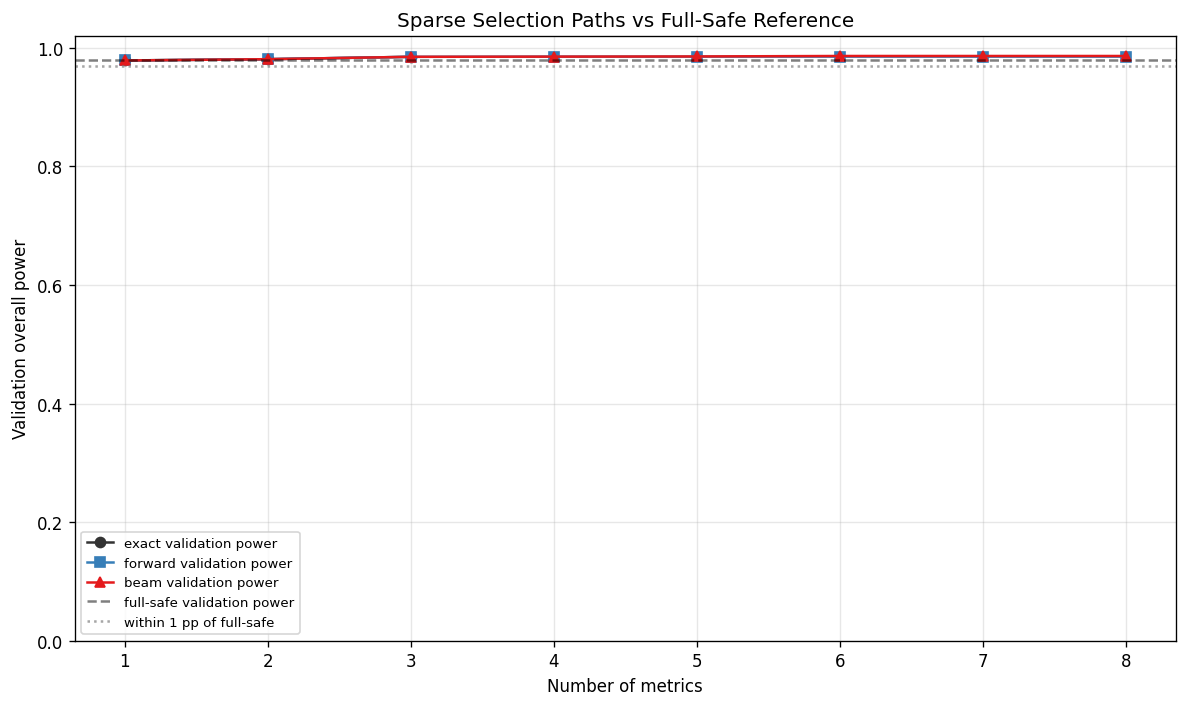

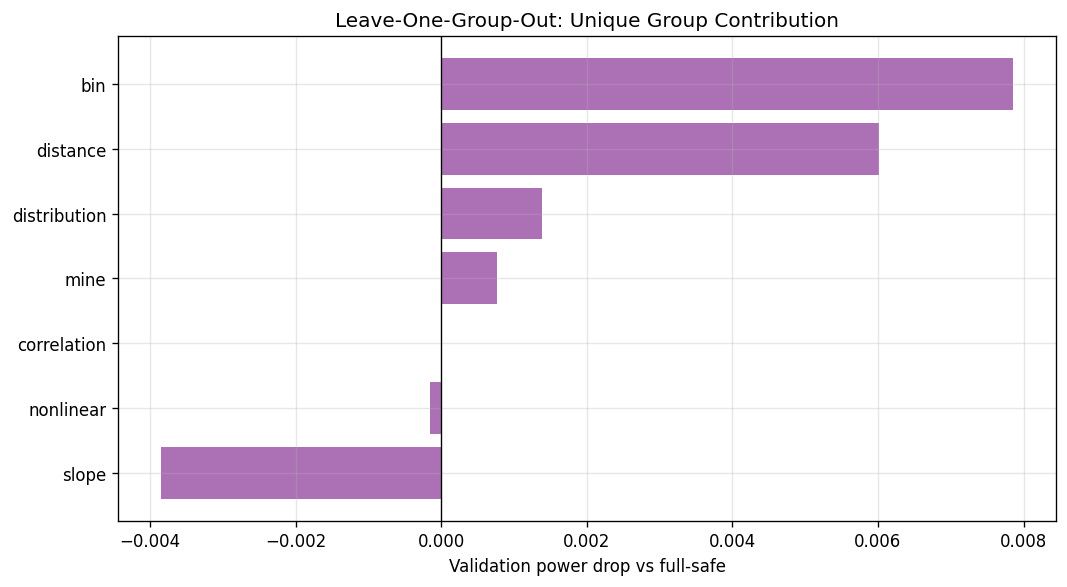

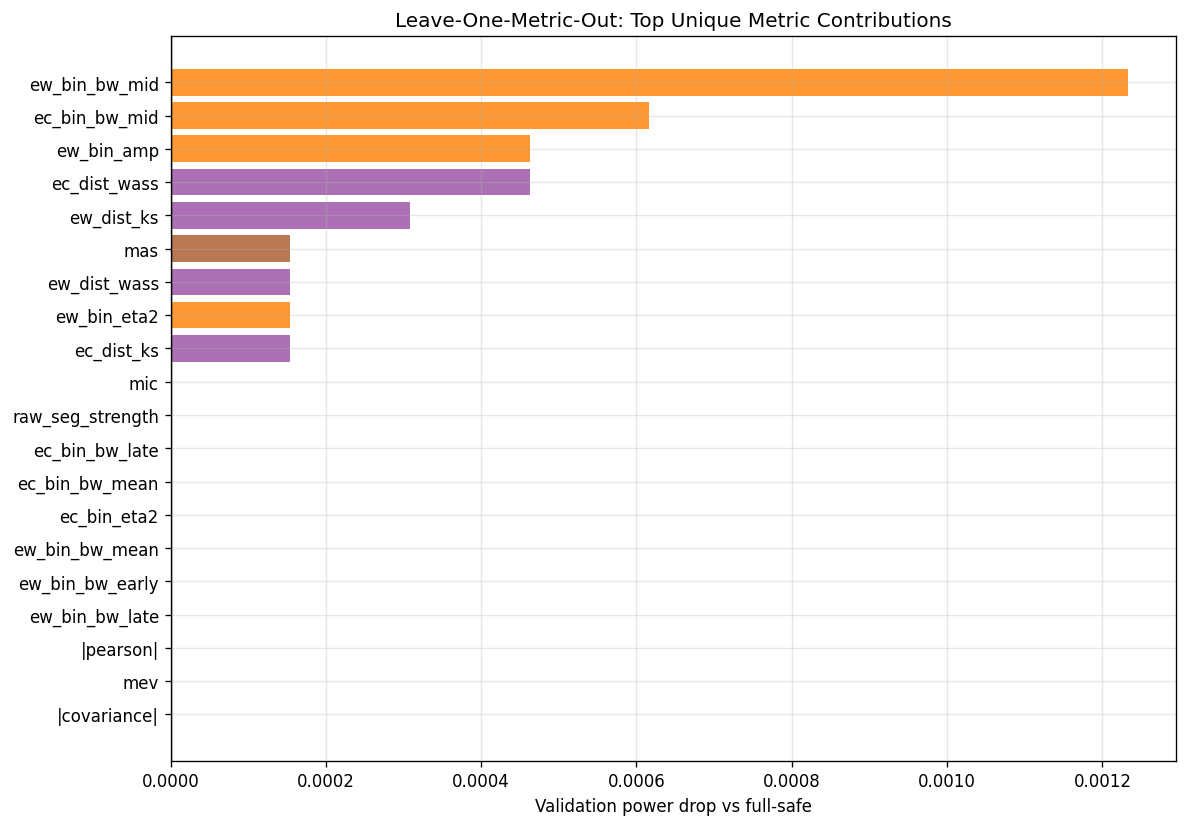

In [36]:
# Sparse paths vs full-safe reference
fig, ax = plt.subplots(figsize=(10, 6))
for method, color, marker in [('exact', '#333333', 'o'), ('forward', '#377eb8', 's'), ('beam', '#e41a1c', '^')]:
    sub = all_sparse[all_sparse['method'] == method]
    if len(sub):
        ax.plot(sub['k'], sub['validation_overall_power'], marker=marker, color=color, label=f'{method} validation power')
ax.axhline(FULL_SAFE_POWER, color='black', ls='--', alpha=0.5, label='full-safe validation power')
ax.axhline(FULL_SAFE_POWER - NEAR_FULL_TOL, color='gray', ls=':', alpha=0.7, label='within 1 pp of full-safe')
ax.set_xlabel('Number of metrics')
ax.set_ylabel('Validation overall power')
ax.set_title('Sparse Selection Paths vs Full-Safe Reference')
ax.set_xticks(sorted(all_sparse['k'].unique()))
ax.set_ylim(0, 1.02)
ax.legend(fontsize=8)
plt.tight_layout()
fig.savefig(OUT_DIR / 'fig1_sparse_paths_vs_full_safe.png', dpi=150, bbox_inches='tight')
plt.show()

# Group ablation drop plot
plot_group = leave_group.sort_values('validation_power_drop_vs_full_safe', ascending=True)
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(plot_group['group_removed'], plot_group['validation_power_drop_vs_full_safe'], color='#984ea3', alpha=0.8)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Validation power drop vs full-safe')
ax.set_title('Leave-One-Group-Out: Unique Group Contribution')
plt.tight_layout()
fig.savefig(OUT_DIR / 'fig2_group_ablation_drop.png', dpi=150, bbox_inches='tight')
plt.show()

# Metric ablation top drops
plot_metric = metric_ablation.head(20).sort_values('validation_power_drop_vs_full_safe', ascending=True)
fig, ax = plt.subplots(figsize=(10, 7))
colors = [GROUP_COLORS.get(g, '#999999') for g in plot_metric['group_removed']]
ax.barh(plot_metric['display_removed'], plot_metric['validation_power_drop_vs_full_safe'], color=colors, alpha=0.8)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Validation power drop vs full-safe')
ax.set_title('Leave-One-Metric-Out: Top Unique Metric Contributions')
plt.tight_layout()
fig.savefig(OUT_DIR / 'fig3_metric_ablation_drop.png', dpi=150, bbox_inches='tight')
plt.show()


## 17. Summary


In [37]:
print('=' * 90)
print('B_S3.3 Metric Selection Summary')
print('=' * 90)
print(f'Train cases: {len(train):,}; validation cases: {len(validation):,}')
print(f'Safe metrics: {len(SAFE_METRICS)}; full-coverage safe metrics: {len(FULL_COVERAGE_SAFE_METRICS)}')
print(f'Full-safe validation power: {FULL_SAFE_POWER:.3f}')
print()
print('Full benchmarks:')
print_eval_table(benchmarks)
print()
print('Most important groups by leave-one-group-out drop:')
print(leave_group[['group_removed', 'validation_power_drop_vs_full_safe', 'validation_overall_power', 'validation_FPR']]
      .to_string(index=False, float_format='{:.4f}'.format))
print()
print('Most important metrics by leave-one-metric-out drop:')
print(metric_ablation[['display_removed', 'group_removed', 'validation_power_drop_vs_full_safe']]
      .head(15).to_string(index=False, float_format='{:.4f}'.format))
print()
print('Sparse candidate best paths:')
print(all_sparse[['method', 'k', 'display_metrics', 'validation_overall_power', 'validation_FPR', 'validation_power_gap_vs_full_safe']]
      .sort_values(['k', 'validation_overall_power'], ascending=[True, False])
      .to_string(index=False, float_format='{:.4f}'.format))
print()
print('Recommended sparse combo:')
print(f'  method: {recommended.get("method", "unknown")}')
print(f'  k: {int(recommended["k"])}')
print(f'  metrics: {recommended["display_metrics"]}')
print(f'  validation overall power: {recommended["validation_overall_power"]:.3f}')
print(f'  validation FPR: {recommended["validation_FPR"]:.3f}')
print(f'  validation power gap vs full-safe: {recommended["validation_power_gap_vs_full_safe"]:.3f}')
print(f'\nSaved outputs to {OUT_DIR}')


B_S3.3 Metric Selection Summary
Train cases: 8,504; validation cases: 8,504
Safe metrics: 43; full-coverage safe metrics: 39
Full-safe validation power: 0.979

Full benchmarks:
             label  k  train_overall_power  train_FPR  validation_overall_power  validation_FPR  validation_MO  validation_VO  validation_MV
       all_metrics 44                0.982      0.050                     0.979           0.062          0.965          0.972          0.998
          all_safe 43                0.982      0.050                     0.979           0.062          0.965          0.972          0.998
full_coverage_safe 39                0.980      0.050                     0.979           0.056          0.966          0.968          0.998

Most important groups by leave-one-group-out drop:
group_removed  validation_power_drop_vs_full_safe  validation_overall_power  validation_FPR
          bin                              0.0079                    0.9713          0.0556
     distance          